# Trabajo Final del Curso
## Fundamentos y Algoritmia para Inteligencia Artificial

En este trabajo voy a realizar las actividades que se solicitaron para el proyecto:
- exploración del dataset y sus 7 características;
- tratamiento de valores nulos;
- normalización con `StandardScaler`;
- operaciones con vectores y matrices;
- producto punto, norma y sistema de ecuaciones;
- estadística de `Area` y `Perimeter`;
- varianza y desviación estándar manual de `Area`;
- detección de valores atípicos con 2 desviaciones estándar;
- histograma y gráfico de dispersión;
- comparación de K-Vecinos y Árbol de Decisión mediante Accuracy.


### 1. Importamos las librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")


### 2. Cargamos y revisamos los datos

Para realizar el trabajo voy a usar un dataset generado con Python. Tiene 210 registros, 3 variedades de trigo y las 7 características que se necesitan.

Las características que voy a utilizar son:

1. `Area`
2. `Perimeter`
3. `Compactness`
4. `Length_of_kernel`
5. `Width_of_kernel`
6. `Asymmetry_coefficient`
7. `Length_of_kernel_groove`

La columna `Class` indica a qué variedad pertenece cada registro.


In [3]:
rng = np.random.default_rng(2026)

caracteristicas = [
    "Area",
    "Perimeter",
    "Compactness",
    "Length_of_kernel",
    "Width_of_kernel",
    "Asymmetry_coefficient",
    "Length_of_kernel_groove"
]

# Datos que voy a usar para las tres variedades.
perfiles = {
    "Kama": (
        [14.33, 14.29, 0.880, 5.51, 3.24, 2.67, 5.09],
        [1.22, 0.58, 0.016, 0.23, 0.18, 1.17, 0.26]
    ),
    "Rosa": (
        [18.33, 16.14, 0.884, 6.15, 3.68, 3.64, 6.02],
        [1.44, 0.62, 0.016, 0.27, 0.18, 1.18, 0.25]
    ),
    "Canadian": (
        [11.87, 13.25, 0.849, 5.23, 2.85, 4.79, 5.12],
        [0.72, 0.34, 0.022, 0.14, 0.15, 1.34, 0.16]
    )
}

# Relación entre las características para generar los datos.
correlacion = np.array([
    [1.00, 0.97, 0.60, 0.95, 0.97, -0.23, 0.86],
    [0.97, 1.00, 0.52, 0.97, 0.94, -0.22, 0.89],
    [0.60, 0.52, 1.00, 0.37, 0.76, -0.33, 0.23],
    [0.95, 0.97, 0.37, 1.00, 0.86, -0.17, 0.93],
    [0.97, 0.94, 0.76, 0.86, 1.00, -0.26, 0.75],
    [-0.23, -0.22, -0.33, -0.17, -0.26, 1.00, -0.01],
    [0.86, 0.89, 0.23, 0.93, 0.75, -0.01, 1.00]
])

# Ajusto la matriz para poder generar los datos.
valores, vectores = np.linalg.eigh(correlacion)
correlacion = vectores @ np.diag(np.clip(valores, 1e-6, None)) @ vectores.T

diagonal = np.sqrt(np.diag(correlacion))
correlacion = correlacion / np.outer(diagonal, diagonal)

partes = []

for nombre, (medias, desviaciones) in perfiles.items():
    covarianza = correlacion * np.outer(desviaciones, desviaciones)

    grupo = pd.DataFrame(
        rng.multivariate_normal(
            medias,
            covarianza,
            size=70
        ),
        columns=caracteristicas
    ).round(3)

    grupo["Class"] = nombre
    partes.append(grupo)

df = pd.concat(partes, ignore_index=True)

# Mezclo los registros para que no estén ordenados por variedad.
df = df.sample(frac=1, random_state=2026).reset_index(drop=True)

# Coloco algunos valores vacíos para practicar su tratamiento.
for columna, cantidad in [
    ("Compactness", 4),
    ("Asymmetry_coefficient", 3)
]:
    indices = rng.choice(len(df), cantidad, replace=False)
    df.loc[indices, columna] = np.nan

# Guardo los datos que voy a utilizar en el proyecto.
df.to_csv("seeds_sintetico.csv", index=False)

print("Primeras filas del dataset:")
display(df.head())


Primeras filas del dataset:


,Area,Perimeter,Compactness,Length_of_kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove,Class
0,14.451,14.261,0.890,5.483,3.280,4.121,5.140,Kama
1,14.730,14.557,0.899,5.563,3.344,0.740,5.103,Kama
2,13.778,14.016,0.876,5.418,3.163,3.620,4.927,Kama
3,12.624,13.640,0.837,5.447,2.933,5.154,5.443,Canadian
4,11.199,13.037,0.831,5.125,2.721,3.286,4.976,Canadian


In [4]:
print("Dimensiones del dataset:", df.shape)

print("\nNombres de las columnas:")
print(df.columns.tolist())

print("\nLas 7 características son:")
for caracteristica in caracteristicas:
    print("-", caracteristica)

print("\nCantidad de características:", len(caracteristicas))

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nCantidad total de valores nulos:", df.isnull().sum().sum())

print("\nCantidad de registros por variedad:")
print(df["Class"].value_counts())

print("\nInformación estadística:")
display(df.describe())


Dimensiones del dataset: (210, 8)

Nombres de las columnas:
['Area', 'Perimeter', 'Compactness', 'Length_of_kernel', 'Width_of_kernel', 'Asymmetry_coefficient', 'Length_of_kernel_groove', 'Class']

Las 7 características son:
- Area
- Perimeter
- Compactness
- Length_of_kernel
- Width_of_kernel
- Asymmetry_coefficient
- Length_of_kernel_groove

Cantidad de características: 7

Valores nulos por columna:
Area                       0
Perimeter                  0
Compactness                4
Length_of_kernel           0
Width_of_kernel            0
Asymmetry_coefficient      3
Length_of_kernel_groove    0
Class                      0
dtype: int64

Cantidad total de valores nulos: 7

Cantidad de registros por variedad:
Class
Kama        70
Canadian    70
Rosa        70
Name: count, dtype: int64

Información estadística:


,Area,Perimeter,Compactness,Length_of_kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove
count,210.000000,210.000000,206.000000,210.000000,210.000000,207.000000,210.000000
mean,14.908867,14.593971,0.871524,5.645881,3.266762,3.828290,5.425910
std,2.972858,1.337258,0.023991,0.459649,0.385961,1.556028,0.492785
min,10.016000,12.316000,0.814000,4.726000,2.516000,0.142000,4.167000
25%,12.408500,13.439000,0.859000,5.277500,2.968250,2.917500,5.067000
50%,14.177500,14.200000,0.872000,5.483500,3.232500,3.683000,5.257500
75%,17.222000,15.662500,0.887750,5.999250,3.573750,4.865500,5.841000
max,22.316000,17.907000,0.938000,6.842000,4.184000,9.204000,6.680000


### 3. Separamos los datos y hacemos la normalización

Primero voy a reemplazar los valores que faltan usando la mediana de cada columna numérica.

Después separo los datos en dos partes:
- `X`: las 7 características predictoras.
- `y`: la variable `Class`.

Después uso `StandardScaler` para normalizar las características.

Para los modelos también se normalizan los datos, pero primero se separan en entrenamiento y prueba para trabajar correctamente.


In [5]:
df_limpio = df.copy()

for columna in caracteristicas:
    df_limpio[columna] = df_limpio[columna].fillna(
        df_limpio[columna].median()
    )

print("Valores nulos después del tratamiento:",
      df_limpio[caracteristicas].isnull().sum().sum())

X = df_limpio[caracteristicas]
y = df_limpio["Class"]

scaler = StandardScaler()
X_normalizado = scaler.fit_transform(X)

X_normalizado = pd.DataFrame(
    X_normalizado,
    columns=caracteristicas
)

print("\nPrimeras filas de los datos normalizados:")
display(X_normalizado.head())

print("\nMedia de las variables normalizadas:")
print(X_normalizado.mean().round(3))

print("\nDesviación estándar de las variables normalizadas:")
print(X_normalizado.std(ddof=0).round(3))


Valores nulos después del tratamiento: 0

Primeras filas de los datos normalizados:


,Area,Perimeter,Compactness,Length_of_kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove
0,-0.154384,-0.249591,0.779061,-0.355206,0.034381,0.191266,-0.581578
1,-0.060310,-0.027713,1.158748,-0.180745,0.200597,-2.002430,-0.656841
2,-0.381306,-0.433239,0.188437,-0.496957,-0.269483,-0.133798,-1.014848
3,-0.770412,-0.715083,-1.456872,-0.433714,-0.866822,0.861508,0.034764
4,-1.250894,-1.167083,-1.709996,-1.135923,-1.417413,-0.350508,-0.915175



Media de las variables normalizadas:
Area                       0.0
Perimeter                 -0.0
Compactness                0.0
Length_of_kernel          -0.0
Width_of_kernel           -0.0
Asymmetry_coefficient     -0.0
Length_of_kernel_groove    0.0
dtype: float64

Desviación estándar de las variables normalizadas:
Area                       1.0
Perimeter                  1.0
Compactness                1.0
Length_of_kernel           1.0
Width_of_kernel            1.0
Asymmetry_coefficient      1.0
Length_of_kernel_groove    1.0
dtype: float64


### 4. Trabajamos con vectores y matrices usando NumPy

Para esta parte tomo algunos valores de `Area` y `Perimeter` y los convierto en vectores.

Con estos datos voy a calcular:
- producto punto;
- norma de los vectores;
- una matriz de datos y su transpuesta.


In [6]:
vector_a = df_limpio["Area"].values[:4]
vector_b = df_limpio["Perimeter"].values[:4]

producto_punto = np.dot(vector_a, vector_b)

norma_a = np.linalg.norm(vector_a)
norma_b = np.linalg.norm(vector_b)

print("Vector A:", vector_a)
print("Vector B:", vector_b)

print("\nProducto punto:", round(producto_punto, 3))
print("Norma del vector A:", round(norma_a, 3))
print("Norma del vector B:", round(norma_b, 3))

matriz = df_limpio[
    ["Area", "Perimeter", "Compactness"]
].values[:3]

print("\nMatriz:")
print(matriz)

print("\nMatriz transpuesta:")
print(matriz.T)


Vector A: [14.451 14.73  13.778 12.624]
Vector B: [14.261 14.557 14.016 13.64 ]

Producto punto: 785.814
Norma del vector A: 27.839
Norma del vector B: 28.245

Matriz:
[[14.451 14.261  0.89 ]
 [14.73  14.557  0.899]
 [13.778 14.016  0.876]]

Matriz transpuesta:
[[14.451 14.73  13.778]
 [14.261 14.557 14.016]
 [ 0.89   0.899  0.876]]


### 5. Resolvemos un sistema de ecuaciones

Ahora voy a resolver el siguiente sistema de ecuaciones usando NumPy:

- `2x + y - z = 3`
- `x + 3y + 2z = 9`
- `3x - y + z = 2`


In [7]:
A = np.array([
    [2, 1, -1],
    [1, 3, 2],
    [3, -1, 1]
])

b = np.array([3, 9, 2])

solucion = np.linalg.solve(A, b)

print("Matriz A:")
print(A)

print("\nVector b:")
print(b)

print("\nSolución [x, y, z]:")
print(solucion.round(3))

print("\nComprobación A @ solución:")
print((A @ solucion).round(3))


Matriz A:
[[ 2  1 -1]
 [ 1  3  2]
 [ 3 -1  1]]

Vector b:
[3 9 2]

Solución [x, y, z]:
[1. 2. 1.]

Comprobación A @ solución:
[3. 9. 2.]


### 6. Calculamos medidas estadísticas

En esta parte calculo la media, mediana, varianza y desviación estándar de `Area` y `Perimeter`.


In [8]:
for columna in ["Area", "Perimeter"]:
    datos = df_limpio[columna]

    print(f"\n--- {columna} ---")
    print("Media:", round(datos.mean(), 4))
    print("Mediana:", round(datos.median(), 4))
    print("Varianza:", round(datos.var(ddof=1), 4))
    print("Desviación estándar:", round(datos.std(ddof=1), 4))



--- Area ---
Media: 14.9089
Mediana: 14.1775
Varianza: 8.8379
Desviación estándar: 2.9729

--- Perimeter ---
Media: 14.594
Mediana: 14.2
Varianza: 1.7883
Desviación estándar: 1.3373


### 7. Calculamos la varianza y desviación estándar de forma manual

Primero hago los cálculos con las fórmulas y después los comparo con los resultados de NumPy.

En este caso uso la varianza muestral, por eso se divide entre `n - 1`.


In [9]:
def varianza_manual(datos):
    n = len(datos)
    media = sum(datos) / n

    suma = 0
    for valor in datos:
        suma += (valor - media) ** 2

    return suma / (n - 1)


def desviacion_estandar_manual(datos):
    return varianza_manual(datos) ** 0.5


area = df_limpio["Area"].values

varianza_manual_area = varianza_manual(area)
desviacion_manual_area = desviacion_estandar_manual(area)

varianza_numpy_area = np.var(area, ddof=1)
desviacion_numpy_area = np.std(area, ddof=1)

print("Varianza manual:", round(varianza_manual_area, 6))
print("Varianza con NumPy:", round(varianza_numpy_area, 6))

print("\nDesviación estándar manual:",
      round(desviacion_manual_area, 6))
print("Desviación estándar con NumPy:",
      round(desviacion_numpy_area, 6))

print("\n¿La varianza coincide?",
      np.isclose(varianza_manual_area, varianza_numpy_area))

print("¿La desviación estándar coincide?",
      np.isclose(desviacion_manual_area, desviacion_numpy_area))


Varianza manual: 8.837884
Varianza con NumPy: 8.837884

Desviación estándar manual: 2.972858
Desviación estándar con NumPy: 2.972858

¿La varianza coincide? True
¿La desviación estándar coincide? True


### 8. Buscamos valores atípicos en `Area`

Para encontrar valores atípicos voy a usar el criterio de dos desviaciones estándar.

Considero que un valor es atípico cuando está:
- por debajo de `media - 2 × desviación estándar`, o
- por encima de `media + 2 × desviación estándar`.


In [10]:
media_area = df_limpio["Area"].mean()
desviacion_area = df_limpio["Area"].std(ddof=1)

limite_inferior = media_area - 2 * desviacion_area
limite_superior = media_area + 2 * desviacion_area

atipicos = df_limpio[
    (df_limpio["Area"] < limite_inferior) |
    (df_limpio["Area"] > limite_superior)
]

print("Media de Area:", round(media_area, 4))
print("Desviación estándar:", round(desviacion_area, 4))
print("Límite inferior:", round(limite_inferior, 4))
print("Límite superior:", round(limite_superior, 4))

print("\nCantidad de valores atípicos:",
      len(atipicos))

display(atipicos[["Area", "Class"]])


Media de Area: 14.9089
Desviación estándar: 2.9729
Límite inferior: 8.9632
Límite superior: 20.8546

Cantidad de valores atípicos: 5


,Area,Class
18,21.171,Rosa
35,21.598,Rosa
61,21.437,Rosa
125,22.316,Rosa
202,21.364,Rosa


### 9. Gráficos estadísticos

Se genera:
1. un histograma de `Area`;
2. un gráfico de dispersión de `Area` frente a `Perimeter`, diferenciando las tres variedades.

Los gráficos se realizan con Matplotlib y Seaborn, tal como contempla la pauta oficial.


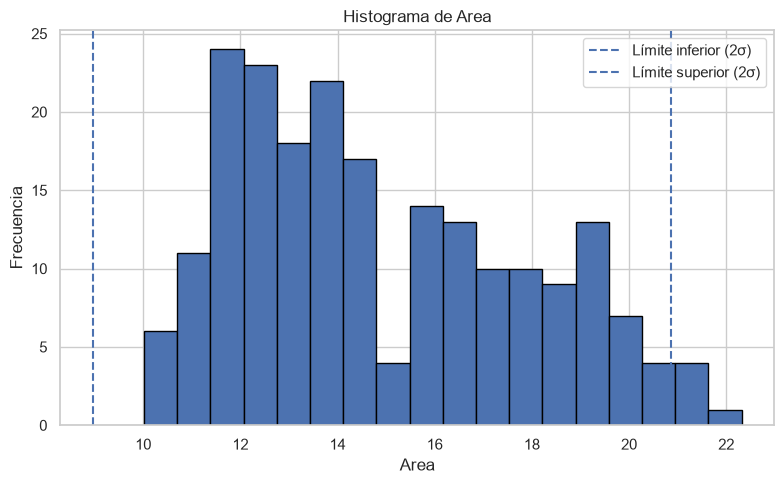

In [11]:
# Histograma de Area
plt.figure(figsize=(8, 5))

plt.hist(
    df_limpio["Area"],
    bins=18,
    edgecolor="black"
)

plt.axvline(
    limite_inferior,
    linestyle="--",
    label="Límite inferior (2σ)"
)

plt.axvline(
    limite_superior,
    linestyle="--",
    label="Límite superior (2σ)"
)

plt.title("Histograma de Area")
plt.xlabel("Area")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()


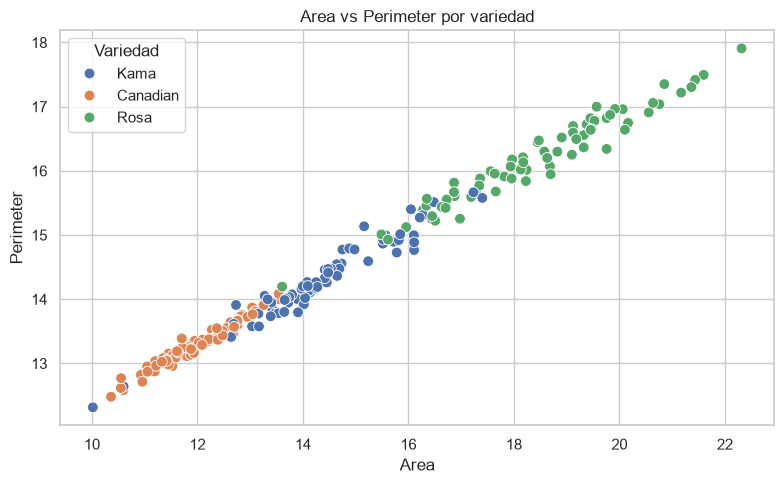

In [12]:
# Gráfico de dispersión Area vs Perimeter
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_limpio,
    x="Area",
    y="Perimeter",
    hue="Class",
    s=60
)

plt.title("Area vs Perimeter por variedad")
plt.xlabel("Area")
plt.ylabel("Perimeter")
plt.legend(title="Variedad")
plt.tight_layout()
plt.show()


### 10. Separar datos de entrenamiento y prueba

Se utiliza una división de:
- 75 % para entrenamiento;
- 25 % para prueba.

`stratify=y` mantiene la proporción de las tres variedades.

El `StandardScaler` se ajusta **solo con los datos de entrenamiento** y luego se aplica a entrenamiento y prueba.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=7,
    stratify=y
)

escalador_modelo = StandardScaler()

X_train_normalizado = escalador_modelo.fit_transform(X_train)
X_test_normalizado = escalador_modelo.transform(X_test)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)


Datos de entrenamiento: (157, 7)
Datos de prueba: (53, 7)


### 11. Modelo K-Vecinos

Se entrena `KNeighborsClassifier` con `k = 7` y se evalúa mediante Accuracy.


In [14]:
modelo_knn = KNeighborsClassifier(n_neighbors=7)

modelo_knn.fit(
    X_train_normalizado,
    y_train
)

predicciones_knn = modelo_knn.predict(
    X_test_normalizado
)

accuracy_knn = accuracy_score(
    y_test,
    predicciones_knn
)

print("Accuracy de K-Vecinos:",
      round(accuracy_knn, 4))


Accuracy de K-Vecinos: 0.9434


### 12. Modelo Árbol de Decisión

Se entrena `DecisionTreeClassifier` y se evalúa mediante Accuracy.


In [15]:
modelo_arbol = DecisionTreeClassifier(
    max_depth=4,
    random_state=7
)

modelo_arbol.fit(
    X_train_normalizado,
    y_train
)

predicciones_arbol = modelo_arbol.predict(
    X_test_normalizado
)

accuracy_arbol = accuracy_score(
    y_test,
    predicciones_arbol
)

print("Accuracy del Árbol de Decisión:",
      round(accuracy_arbol, 4))


Accuracy del Árbol de Decisión: 0.9434


### 13. Comparación de los modelos

Se comparan los valores de Accuracy obtenidos por K-Vecinos y Árbol de Decisión.


In [16]:
print("========== COMPARACIÓN ==========")
print("K-Vecinos (k=7):",
      round(accuracy_knn, 4))
print("Árbol de Decisión:",
      round(accuracy_arbol, 4))

if accuracy_knn > accuracy_arbol:
    print("\nK-Vecinos obtuvo el mayor Accuracy.")

elif accuracy_arbol > accuracy_knn:
    print("\nÁrbol de Decisión obtuvo el mayor Accuracy.")

else:
    print("\nAmbos modelos obtuvieron el mismo Accuracy.")


========== COMPARACIÓN ==========
K-Vecinos (k=7): 0.9434
Árbol de Decisión: 0.9434

Ambos modelos obtuvieron el mismo Accuracy.


## 14. Conclusiones

- El dataset fue explorado utilizando Pandas y se identificaron sus 7 características predictoras y la variable `Class`.
- Los valores nulos fueron tratados antes de utilizar los datos en los modelos.
- La normalización con `StandardScaler` permitió trabajar con las características en una escala comparable.
- NumPy permitió realizar operaciones con vectores y matrices, calcular el producto punto, la norma y resolver un sistema de ecuaciones.
- Se calcularon las medidas estadísticas de `Area` y `Perimeter`.
- La varianza y la desviación estándar de `Area` fueron implementadas manualmente y comparadas con NumPy.
- Los valores atípicos de `Area` fueron identificados mediante el criterio de dos desviaciones estándar.
- Los gráficos permitieron observar la distribución de `Area` y la relación entre `Area` y `Perimeter` para las tres variedades.
- Finalmente, se entrenaron y compararon K-Vecinos y Árbol de Decisión mediante Accuracy. El modelo con mayor Accuracy en la ejecución del notebook es el que presenta el mejor resultado entre los dos modelos evaluados.
